# 02 · The walk — tune its hyperparameters on train, judge them on test

## Executive summary (read this first)

The baseline model is the **cumulative random walk with Cholesky**. Production fixes its settings (a 260-step
window, no extra width). Here they become **hyperparameters**, chosen on
the **train** dates of notebook 01 and judged on the **test** dates, with **each card's own score** from its
`card.toml` (raw, no M0).

| hyperparameter | what it does | values tried | production |
|---|---|---|---|
| `window` | how many past steps the sd and correlation are measured on | 21, 42, 65, 130, 260, 520, 1040 | 260 |
| `widen` | multiply the width (the fixed walk's 90 % band catches only 83–87 %) | 0.9, 1.0, 1.1, 1.2, 1.3 | 1.0 |

**Three blocks of dates, used in order** (notebook 01 split them by time, with a purge gap between blocks):

1. **train** — tune: stage 1 tries every `window`, stage 2 then tries `widen` on the chosen window. Three ways of choosing
   come out of it: **one setting for all cards**, **one per family**, **one per card**.
2. **validation** — choose the **way**: the three ways and the fixed walk are scored on validation, and the way
   with the best score relative to the fixed walk is kept (if none beats it, the fixed walk is kept).
3. **test** — hidden until the end, opened **once**: only the final choice and the fixed walk are scored on
   it. Nothing is chosen on test.

Scores are raw (card units), so a card chooses by its own mean score, and a choice across cards uses each
card's score **relative to the fixed walk** (geometric mean). Every setting at a date uses the same random
numbers.

The model function `walk_forecast` gives **exactly** production's draws at production's settings, and
`card_score` gives **exactly** the official scorer's number (§3). Reads `data/targets.parquet` and
`data/steps.parquet` from notebook 01. No realized outcome is read.

## 0 — Setup and data

In [1]:
import contextlib, io, json, multiprocessing as mp, pathlib, subprocess, sys, tempfile, time, tomllib
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "model_baseline" else pathlib.Path.cwd() / "model_baseline"
REPO, DATA, UNITS = HERE.parent, HERE / "data", HERE.parent / "units"
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_rows", 120)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
FAM = {"T2-F1": "#2a78d6", "T2-F2": "#eb6834", "T2-F3": "#1baf7a", "T2-F4": "#4a3aa7"}
STRAT = {"fixed 260": "#8a8983", "one for all": "#2a78d6", "one per family": "#eb6834", "one per card": "#1baf7a"}
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})

TARGETS = pd.read_parquet(DATA / "targets.parquet")
STEPS = pd.read_parquet(DATA / "steps.parquet")
CARDS = {u: tomllib.loads((UNITS / u / "card.toml").read_text()) for u in sorted(TARGETS.unit.unique())}
WORKERS = max(1, (mp.cpu_count() or 2) - 2)
geo = lambda r: float(np.exp(np.log(np.asarray(r, float)).mean()))
print(f"{len(CARDS)} cards; {len(TARGETS):,} target rows; {len(STEPS):,} step rows; {WORKERS} worker processes")

103 cards; 1,118,320 target rows; 698,297 step rows; 10 worker processes


## 1 — The model, with its hyperparameters

`walk_forecast(steps, origin, anchor, ksteps, horizons, window, widen)`:

1. take the last `window` steps up to the origin;
2. `sd` = sd of those steps × `widen`; `corr` = their correlation; `L` = its Cholesky factor;
3. one path per draw through the horizons: add `z @ L.T × sd × √(new steps)`; value = anchor + path.

At `window=260, widen=1` this is exactly production's walk (checked in §3). A step is one row of the card's
panel: a business day on a daily panel, a month on a monthly one (4 cards), so `window` counts rows too.

In [2]:
MIN_CHANGES = 10     # fewer steps than this: no honest sd or correlation

def walk_forecast(steps, origin, anchor, ksteps, horizons, window=260, widen=1.0, n_draws=1000, seed=0):
    """Cumulative random walk with Cholesky. Returns draws (n_draws, n_assets, n_horizons)."""
    i = steps.index.searchsorted(pd.Timestamp(origin), side="right")
    past = steps.to_numpy()[max(0, i - window): i]                        # (rows, assets)
    if len(past) < MIN_CHANGES:
        raise ValueError(f"only {len(past)} steps before {origin} (window {window})")
    n_a = past.shape[1]

    D = np.ascontiguousarray(past.T)                                       # asset x step (production's layout)
    sd = D.std(axis=1) * widen
    with np.errstate(invalid="ignore", divide="ignore"):                 # a flat series has no correlation:
        corr = np.nan_to_num(np.atleast_2d(np.corrcoef(D)), nan=0.0)       # it becomes 0, as in production
    np.fill_diagonal(corr, 1.0)
    w, v = np.linalg.eigh(corr)
    corr = v @ np.diag(np.clip(w, 1e-8, None)) @ v.T
    L = np.linalg.cholesky(corr)

    rng = np.random.default_rng(seed)
    out = np.empty((n_draws, n_a, len(horizons)))
    path, prev = np.zeros((n_draws, n_a)), np.zeros(n_a)
    for hi in np.argsort(horizons):
        z = rng.standard_normal((n_draws, n_a)) @ L.T
        rng.standard_normal((n_draws, n_a))                                # production's skew draw (unused)
        kk = np.asarray(ksteps, float)[:, hi]
        path = path + z * sd * np.sqrt(np.maximum(kk - prev, 0))
        prev = kk
        out[:, :, hi] = np.asarray(anchor, float) + path
    return out

## 2 — The score, and one card's inputs

`card_score` = the card's own `[scoring.params]` through the official composite function (on a one-cell
card the variogram's weight is spread over the other two, as the official scorer does). No M0 scale.

In [3]:
from qfbench2_track_forecasting import scoring as S

def card_score(card, samples, y):
    """samples (n_draws, n_cells) in card order; y (n_cells,). Lower is better."""
    p = card.get("scoring", {}).get("params", {})
    w = p.get("weights", {"marginal": 0.5, "joint": 0.3, "tail": 0.2})
    w = (float(w["marginal"]), float(w["joint"]), float(w["tail"]))
    if samples.shape[1] == 1:
        live = w[0] + w[2]; w = (w[0] / live, 0.0, w[2] / live)
    out = S._composite(samples, y, weights=w, tail_levels=tuple(p.get("tail_levels", (0.01, 0.05, 0.95, 0.99))),
                       joint=S.card_joint_statistic(card), tail_metric=str(p.get("tail_metric", S.DEFAULT_TAIL_METRIC)),
                       ref_scale=None)
    q = np.quantile(samples, [0.05, 0.25, 0.75, 0.95], axis=0)
    return {**out, "cov50": float(np.mean((y >= q[1]) & (y <= q[2]))), "cov90": float(np.mean((y >= q[0]) & (y <= q[3])))}

def card_inputs(u):
    """(card, assets, horizons, steps date x asset in card order, targets indexed by origin/asset/horizon)."""
    card = CARDS[u]; t = card["targets"]
    assets, horizons = [str(a) for a in t["asset_ids"]], [int(h) for h in t["horizons"]]
    steps = STEPS[STEPS.unit == u].pivot(index="date", columns="asset", values="step")[assets].sort_index()
    tt = TARGETS[TARGETS.unit == u].set_index(["origin_date", "asset", "horizon"]).sort_index()
    return card, assets, horizons, steps, tt

def at_origin(tt, origin, assets, horizons):
    r = tt.loc[origin]
    anchor = np.array([r.loc[(a, horizons[0]), "anchor"] for a in assets])
    ksteps = np.array([[r.loc[(a, h), "steps"] for h in horizons] for a in assets])
    y = np.array([r.loc[(a, h), "target"] for a in assets for h in horizons])
    return anchor, ksteps, y

## 3 — Checks: production's walk and the official scorer

1. At production's settings (`window=260, widen=1`), `walk_forecast` gives the same 1,000 draws as
   `forecast_models` (3 cards x 3 test dates).
2. `card_score` gives the official `scoring/scoring.py` number (a 4-cell and a 1-cell card).

In [4]:
import forecast_agent as fa, forecast_models as fm
rows = []
for u in ["t2-F3-boj-ust-channel-2023", "t2-F4-short-vol-2018", "t2-F1-pause-2006"]:
    card, assets, horizons, steps, tt = card_inputs(u); t = card["targets"]
    panels = fa._read_panels(UNITS / u)
    test_dates = np.sort(tt[tt.split == "test"].index.get_level_values(0).unique())
    for o in test_dates[[0, len(test_dates) // 2, -1]]:
        anchor, ksteps, y = at_origin(tt, o, assets, horizons)
        mine = walk_forecast(steps, o, anchor, ksteps, horizons, seed=7)
        req = fm._Request(panels, assets, horizons, str(pd.Timestamp(o).date()), {a: {} for a in assets}, 1000, 7,
                          t["target_type"], None)   # family None: production's plain walk (260 / 1.0 / normal)
        prod = (fm._cumulative_walk_model if len(horizons) > 1 else fm._random_walk_model)(req)
        rows.append({"card": u, "test date": pd.Timestamp(o).date(), "max |mine - production|": float(np.abs(mine - prod).max())})
check1 = pd.DataFrame(rows); display(check1); assert (check1["max |mine - production|"] == 0).all()

def official_score(u, samples3, y, assets, horizons):
    card = CARDS[u]; t = card["targets"]
    with tempfile.TemporaryDirectory() as tmp:
        out_dir, real = pathlib.Path(tmp) / "out", pathlib.Path(tmp) / "realized.parquet"; out_dir.mkdir()
        pd.DataFrame([{"draw": np.int32(d), "asset": a, "horizon": np.int32(h), "value": float(samples3[d, ai, hi])}
                      for d in range(samples3.shape[0]) for ai, a in enumerate(assets) for hi, h in enumerate(horizons)]
                     ).to_parquet(out_dir / "forecast.parquet", index=False)
        (out_dir / "forecast_meta.json").write_text(json.dumps({"unit_id": card["task"]["id"], "asof": card["provenance"]["data_cutoff"],
            "representation": "samples", "asset_ids": assets, "horizons": horizons, "n_draws": samples3.shape[0], "target": t["target_type"]}))
        (out_dir / "forecast_rationale.md").write_text("# backtest check\n")
        pd.DataFrame([{"asset": a, "horizon": h, "value": float(v)} for (a, h), v in
                      zip([(a, h) for a in assets for h in horizons], y)]).to_parquet(real, index=False)
        r = subprocess.run([sys.executable, str(REPO / "scoring" / "scoring.py"), "score", "--card", str(UNITS / u / "card.toml"),
                            "--forecast", str(out_dir / "forecast.parquet"), "--realized", str(real)], capture_output=True, text=True, cwd=REPO)
        return json.loads(r.stdout)["composite_score"]

rows = []
for u in ["t2-F3-boj-ust-channel-2023", "t2-F4-short-vol-2018"]:
    card, assets, horizons, steps, tt = card_inputs(u)
    o = np.sort(tt[tt.split == "test"].index.get_level_values(0).unique())[100]
    anchor, ksteps, y = at_origin(tt, o, assets, horizons)
    d3 = walk_forecast(steps, o, anchor, ksteps, horizons, window=130, widen=1.1)     # any settings: the score must match
    rows.append({"card": u, "cells": len(y), "card_score": card_score(card, d3.reshape(len(d3), -1), y)["composite"],
                 "official scorer": official_score(u, d3, y, assets, horizons)})
check2 = pd.DataFrame(rows); check2["equal"] = np.isclose(check2.card_score, check2["official scorer"], rtol=0, atol=1e-12)
display(check2); assert check2.equal.all()

,card,test date,max |mine - production|
0,t2-F3-boj-ust-channel-2023,2016-04-15,0.0
1,t2-F3-boj-ust-channel-2023,2019-10-18,0.0
2,t2-F3-boj-ust-channel-2023,2023-04-20,0.0
3,t2-F4-short-vol-2018,2012-08-03,0.0
4,t2-F4-short-vol-2018,2015-04-20,0.0
5,t2-F4-short-vol-2018,2017-12-26,0.0
6,t2-F1-pause-2006,2004-02-05,0.0
7,t2-F1-pause-2006,2004-12-21,0.0
8,t2-F1-pause-2006,2005-11-03,0.0


,card,cells,card_score,official scorer,equal
0,t2-F3-boj-ust-channel-2023,4,2.671406,2.671406,True
1,t2-F4-short-vol-2018,1,0.038982,0.038982,True


## 4 — The runner: score settings on a card's dates, all cards in parallel

`score_card` forecasts and scores a list of settings on one card's train or test dates. Every setting at a
date uses the **same random numbers** (the seed is the date's position), so differences between settings are
differences of the settings, not of luck. Dates with too little history for any setting are left out for all
of them. Cards run in parallel worker processes.

In [5]:
def score_card(args):
    u, split, settings, stride, n_draws, keep_pit = args
    card, assets, horizons, steps, tt = card_inputs(u)
    sub = tt[tt.split == split]
    origins = np.sort(sub.index.get_level_values(0).unique())[::stride]
    fam = card["metadata"]["category"]
    cells = [(a, h) for a in assets for h in horizons]
    rows, pits = [], []
    for j, o in enumerate(origins):
        anchor, ksteps, y = at_origin(sub, o, assets, horizons)
        try:
            draws = [walk_forecast(steps, o, anchor, ksteps, horizons, n_draws=n_draws, seed=j, **s).reshape(n_draws, -1)
                     for s in settings]
        except ValueError:
            continue                                                       # not enough history for some setting
        for s, d in zip(settings, draws):
            rows.append({"unit": u, "family": fam, "split": split, "origin": o, **s, **card_score(card, d, y)})
            if keep_pit:
                pits += [{"unit": u, "family": fam, "origin": o, **s, "asset": a, "horizon": h, "pit": float(p)}
                         for (a, h), p in zip(cells, (d < y).mean(axis=0))]
    return rows, pits

def run(jobs):
    """jobs: list of score_card args. Returns (scores, pits) DataFrames."""
    with mp.get_context("fork").Pool(WORKERS) as pool:
        out = pool.map(score_card, jobs, chunksize=1)
    return pd.DataFrame([r for rows, _ in out for r in rows]), pd.DataFrame([p for _, pits in out for p in pits])

BASE = {"window": 260, "widen": 1.0}
key = lambda s: f'{int(s["window"])} / {float(s["widen"]):.1f}'                      # "window / widen"

## 5 — Stage 1: `window`, on train

Every 21st train date of every card, 500 draws, every window.

stage 1: 7 settings x 8,671 train dates = 60,697 scored forecasts, 3s


window,21,42,65,130,260,520,1040
score ÷ fixed walk,1.014,1.008,1.003,0.998,1.0,1.005,1.008


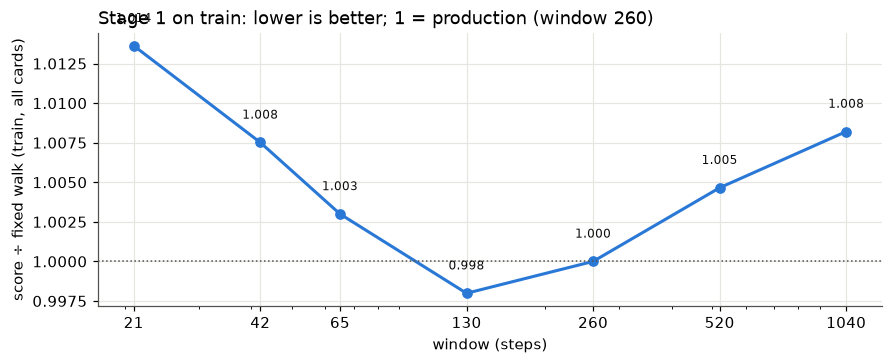

In [6]:
WINDOWS, WIDENS = [21, 42, 65, 130, 260, 520, 1040], [0.9, 1.0, 1.1, 1.2, 1.3]
GRID1 = [{"window": w, "widen": 1.0} for w in WINDOWS]
t0 = time.time()
tr1, _ = run([(u, "train", GRID1, 21, 500, False) for u in CARDS])
print(f"stage 1: {len(GRID1)} settings x {tr1.groupby('unit').origin.nunique().sum():,} train dates = {len(tr1):,} scored forecasts, {time.time() - t0:.0f}s")

def rank(scores, by_card_cols):
    """Mean train score per card and setting, and its ratio to the fixed walk on the same card."""
    m = scores.groupby(["unit", "family", *by_card_cols]).composite.mean().rename("score").reset_index()
    base = m[(m.window == 260) & (m.widen == 1.0)].set_index("unit").score
    return m.assign(ratio=m.score / m.unit.map(base))

m1 = rank(tr1, ["window", "widen"])
curve = m1.groupby("window").ratio.apply(geo)
display(curve.round(3).rename("score ÷ fixed walk").to_frame().T)

fig, ax = plt.subplots(figsize=(8, 3.2), layout="constrained")
ax.plot(curve.index, curve.to_numpy(), "o-", color="#2a78d6", lw=2, ms=6)
for w, v in curve.items(): ax.text(w, v + 0.0015, f"{v:.3f}", ha="center", fontsize=8, color=INK)
ax.axhline(1, color=INK2, ls=":", lw=1); ax.set_xscale("log"); ax.set_xticks(WINDOWS, [str(w) for w in WINDOWS])
ax.set_xlabel("window (steps)"); ax.set_ylabel("score ÷ fixed walk (train, all cards)")
ax.set_title("Stage 1 on train: lower is better; 1 = production (window 260)"); plt.show()

**The three ways to choose** `window`, all on train:

- **one for all**: the window with the lowest geometric-mean ratio over all cards;
- **one per family**: the same, within each family;
- **one per card**: each card's own lowest mean score.

In [7]:
def choose(m, col):
    one_all = m.groupby(col).ratio.apply(geo).idxmin()
    per_fam = {f: g.groupby(col).ratio.apply(geo).idxmin() for f, g in m.groupby("family")}
    per_card = {u: g.loc[g.score.idxmin(), col] for u, g in m.groupby("unit")}
    return one_all, per_fam, per_card

c1_all, c1_fam, c1_card = choose(m1, "window")
NO_TRAIN = [u for u in CARDS if u not in c1_card]               # no train date with enough history for every setting
for u in NO_TRAIN:
    c1_card[u] = c1_fam[CARDS[u]["metadata"]["category"]]       # such a card takes its family's choice
print(f"cards with no usable train date (too little history before them): {NO_TRAIN or 'none'} -> their family's choice")
print("one for all   : window", int(c1_all))
for f, c in c1_fam.items(): print(f"one per family: {f}  window {int(c)}")
print("\none per card — how many cards chose each window:")
display(pd.Series(c1_card).astype(int).value_counts().sort_index().rename("cards").rename_axis("window").to_frame().T)

cards with no usable train date (too little history before them): none -> their family's choice
one for all   : window 130
one per family: T2-F1  window 42
one per family: T2-F2  window 130
one per family: T2-F3  window 130
one per family: T2-F4  window 260

one per card — how many cards chose each window:


window,21,42,65,130,260,520,1040
cards,6,12,10,27,22,6,20


## 6 — Stage 2: `widen`, on train

For each way of choosing, keep its `window` and try `widen` = 0.9 to 1.3, again on train, and pick the
same way (one value for all, per family, per card).

In [8]:
def stage2_settings(u, fam):
    windows = {int(c1_all), int(c1_fam[fam]), int(c1_card[u]), 260}       # fixed walk kept as the reference
    return [{"window": w, "widen": wd} for w in windows for wd in WIDENS]

t0 = time.time()
tr2, _ = run([(u, "train", stage2_settings(u, CARDS[u]["metadata"]["category"]), 21, 500, False) for u in CARDS])
print(f"stage 2: {len(tr2):,} scored forecasts, {time.time() - t0:.0f}s")
m2 = rank(tr2, ["window", "widen"])

w_all = m2[m2.window == c1_all].groupby("widen").ratio.apply(geo).idxmin()
w_fam = {f: m2[(m2.family == f) & (m2.window == c1_fam[f])].groupby("widen").ratio.apply(geo).idxmin() for f in c1_fam}
w_card = {}
for u in CARDS:
    g = m2[(m2.unit == u) & (m2.window == c1_card[u])]
    w_card[u] = float(g.loc[g.score.idxmin(), "widen"]) if len(g) else float(w_fam[CARDS[u]["metadata"]["category"]])

CHOICE = {"fixed 260": {u: BASE for u in CARDS},
          "one for all": {u: {"window": int(c1_all), "widen": float(w_all)} for u in CARDS},
          "one per family": {u: {"window": int(c1_fam[f]), "widen": float(w_fam[f])}
                             for u in CARDS for f in [CARDS[u]["metadata"]["category"]]},
          "one per card": {u: {"window": int(c1_card[u]), "widen": w_card[u]} for u in CARDS}}
settings_tab = pd.DataFrame({name: {u: key(s) for u, s in ch.items()} for name, ch in CHOICE.items()})
print("chosen (window / widen):")
print("  one for all   :", key(CHOICE["one for all"][next(iter(CARDS))]))
for f in sorted(c1_fam): print(f"  one per family: {f} {key({'window': c1_fam[f], 'widen': w_fam[f]})}")
print("  one per card  : widen chosen", pd.Series(w_card).value_counts().sort_index().to_dict())

stage 2: 112,290 scored forecasts, 5s
chosen (window / widen):
  one for all   : 130 / 1.1
  one per family: T2-F1 42 / 1.1
  one per family: T2-F2 130 / 1.0
  one per family: T2-F3 130 / 1.0
  one per family: T2-F4 260 / 1.1
  one per card  : widen chosen {0.9: 24, 1.0: 31, 1.1: 18, 1.2: 12, 1.3: 18}


## 7 — Choose the way, on validation

The fixed walk and the three ways' settings, scored on every card's **validation** dates (every 5th, 1,000
draws). The way with the lowest ratio to the fixed walk becomes the final choice, provided it is below 1.

validation: 16,484 dates, 61,542 scored forecasts, 4s


,ratio_all,cards_better,inside_50,inside_90
way,,,,
fixed 260,1.000,—,0.551,0.895
one for all,0.996,52/103,0.576,0.916
one per family,0.993,50/103,0.567,0.899
one per card,1.004,40/103,0.574,0.897


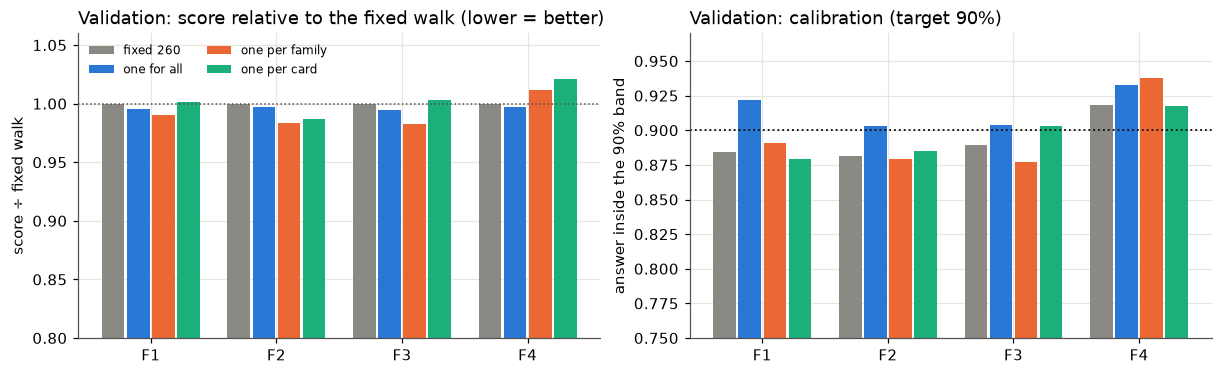

way,fixed 260,one for all,one per family,one per card
family,,,,
T2-F1,1.0,0.995,0.991,1.002
T2-F2,1.0,0.997,0.984,0.987
T2-F3,1.0,0.994,0.983,1.003
T2-F4,1.0,0.997,1.011,1.021


FINAL CHOICE (made on validation): one per family


In [9]:
def compare(split, ways, stride=5, n_draws=1000, keep_pit=False):
    """Score the chosen setting of each way on `split`; ratio to the fixed walk per card."""
    jobs = []
    for u in CARDS:
        uniq = {key(CHOICE[w][u]): CHOICE[w][u] for w in ["fixed 260", *ways]}
        jobs.append((u, split, list(uniq.values()), stride, n_draws, keep_pit))
    sc, pit = run(jobs)
    sc["setting"] = [key(r) for r in sc[["window", "widen"]].to_dict("records")]
    cm = sc.groupby(["unit", "setting"])[["composite", "cov50", "cov90"]].mean()
    rows, scored_units = [], set(sc.unit)
    for w in ["fixed 260", *ways]:
        for u in [u for u in CARDS if u in scored_units]:               # a card with no usable date is left out
            r, b = cm.loc[(u, key(CHOICE[w][u]))], cm.loc[(u, key(BASE))]
            rows.append({"way": w, "unit": u, "family": CARDS[u]["metadata"]["category"],
                         "ratio": r.composite / b.composite, "cov50": r.cov50, "cov90": r.cov90})
    res = pd.DataFrame(rows)
    tab = res.groupby("way").agg(ratio_all=("ratio", geo), cards_better=("ratio", lambda r: f"{(r < 1).sum()}/{len(r)}"),
                                 inside_50=("cov50", "mean"), inside_90=("cov90", "mean")).loc[["fixed 260", *ways]]
    tab.loc["fixed 260", "cards_better"] = "—"
    return sc, pit, res, tab

def plot_compare(res, ways, title):
    by_fam = res.pivot_table(index="family", columns="way", values="ratio", aggfunc=geo)[ways]
    cov = res.pivot_table(index="family", columns="way", values="cov90", aggfunc="mean")[ways]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.3), layout="constrained")
    x = np.arange(len(by_fam)); wb = 0.8 / len(ways)
    for j, w in enumerate(ways):
        off = (j - (len(ways) - 1) / 2) * wb
        axes[0].bar(x + off, by_fam[w], width=wb - 0.02, color=STRAT[w], label=w)
        axes[1].bar(x + off, cov[w], width=wb - 0.02, color=STRAT[w])
    axes[0].axhline(1, color=INK2, ls=":", lw=1); axes[0].set_ylim(min(0.8, float(by_fam.min().min()) - 0.03), 1.06)
    axes[0].set_xticks(x, [f[3:] for f in by_fam.index]); axes[0].set_ylabel("score ÷ fixed walk")
    axes[0].set_title(f"{title}: score relative to the fixed walk (lower = better)"); axes[0].legend(ncols=2, fontsize=8)
    axes[1].axhline(0.9, color=INK, ls=":", lw=1.2); axes[1].set_ylim(0.75, 0.97)
    axes[1].set_xticks(x, [f[3:] for f in cov.index]); axes[1].set_ylabel("answer inside the 90% band")
    axes[1].set_title(f"{title}: calibration (target 90%)"); plt.show()
    return by_fam

t0 = time.time()
WAYS = ["one for all", "one per family", "one per card"]
va, _, va_res, va_tab = compare("validation", WAYS)
print(f"validation: {va.groupby('unit').origin.nunique().sum():,} dates, {len(va):,} scored forecasts, {time.time() - t0:.0f}s")
display(va_tab.round(3))
display(plot_compare(va_res, ["fixed 260", *WAYS], "Validation").round(3))

best_way = va_tab.ratio_all.drop("fixed 260").idxmin()
FINAL = best_way if va_tab.loc[best_way, "ratio_all"] < 1.0 else "fixed 260"
print(f"FINAL CHOICE (made on validation): {FINAL}"
      + ("" if FINAL != "fixed 260" else f"  -- no tuned way beat the fixed walk on validation (best: {best_way}, "
                                          f"{va_tab.loc[best_way, 'ratio_all']:.3f})"))

## 8 — The hidden test set, opened once

Only two forecasts are scored here: the **final choice** from §7 and the **fixed walk**, on every card's test
dates (every 5th, 1,000 draws). If the final choice *is* the fixed walk, this is simply the fixed walk's test
score, with nothing to compare.

test: 24,252 dates, 48,504 scored forecasts, 4s


,ratio_all,cards_better,inside_50,inside_90
way,,,,
fixed 260,1.000,—,0.518,0.859
one per family,1.003,47/103,0.525,0.861


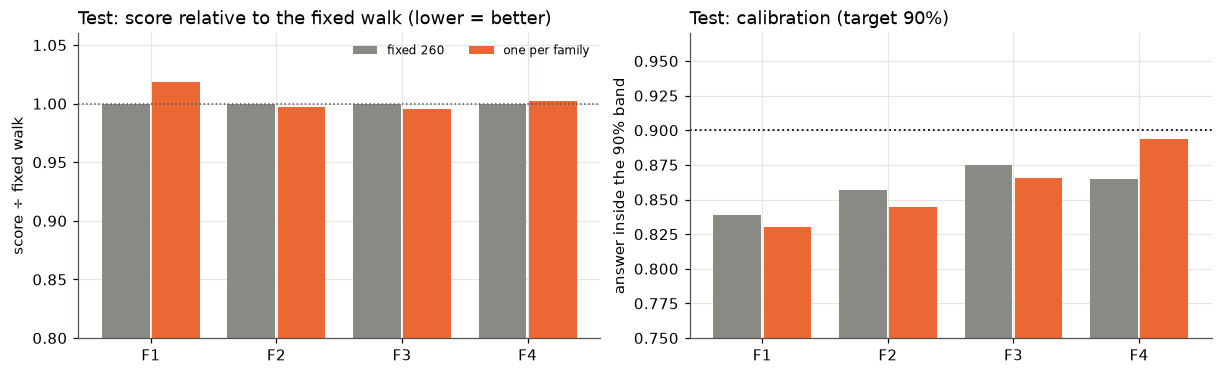

way,fixed 260,one per family
family,,
T2-F1,1.0,1.018
T2-F2,1.0,0.998
T2-F3,1.0,0.996
T2-F4,1.0,1.002


On test, one per family scores 1.003 x the fixed walk: no real difference (within 1%).


In [10]:
t0 = time.time()
final_ways = [] if FINAL == "fixed 260" else [FINAL]
te, te_pit, te_res, te_tab = compare("test", final_ways, keep_pit=True)
print(f"test: {te.groupby('unit').origin.nunique().sum():,} dates, {len(te):,} scored forecasts, {time.time() - t0:.0f}s")
display(te_tab.round(3))
if final_ways:
    display(plot_compare(te_res, ["fixed 260", *final_ways], "Test").round(3))
    r = te_tab.loc[FINAL, "ratio_all"]
    print(f"On test, {FINAL} scores {r:.3f} x the fixed walk: "
          + ("better." if r < 0.99 else "no real difference (within 1%)." if r < 1.01 else "worse."))
else:
    print("Final choice is the fixed walk: its test calibration is above; there is no tuned walk to compare.")

**PIT on test** — flat = calibrated; both ends high = too narrow; one side high = off-centre.

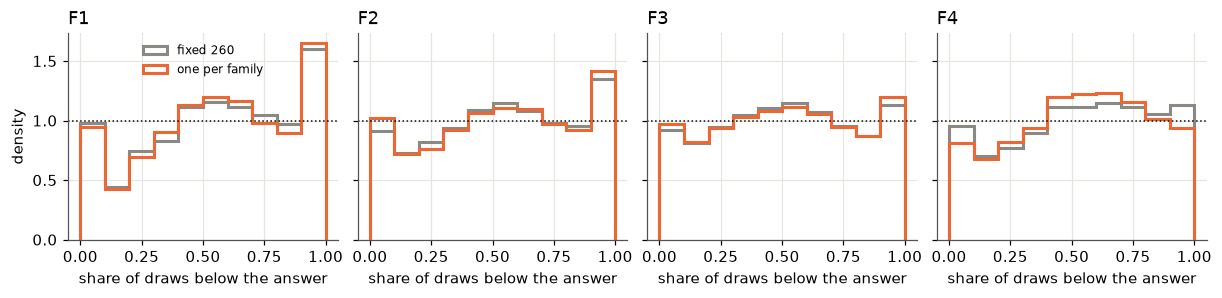

In [11]:
te_pit["setting"] = [key(r) for r in te_pit[["window", "widen"]].to_dict("records")]
fig, axes = plt.subplots(1, 4, figsize=(11, 2.6), layout="constrained", sharey=True)
bins = np.linspace(0, 1, 11)
for ax, f in zip(axes, sorted(FAM)):
    for w in ["fixed 260", *final_ways]:
        mine = pd.Series([key(CHOICE[w][u]) for u in te_pit.unit], index=te_pit.index)
        v = te_pit.loc[(te_pit.family == f) & (te_pit.setting == mine), "pit"]
        ax.hist(v, bins=bins, density=True, histtype="step", lw=2, color=STRAT[w], label=w)
    ax.axhline(1, color=INK, lw=1, ls=":"); ax.set_title(f[3:]); ax.set_xlabel("share of draws below the answer")
axes[0].set_ylabel("density"); axes[0].legend(fontsize=8, loc="upper center"); plt.show()

## 9 — Every card: the setting each way chose, its validation ratio, and the final choice's test ratio

In [12]:
card_tab = va_res[va_res.way != "fixed 260"].pivot_table(index=["family", "unit"], columns="way", values="ratio")[WAYS]
card_tab.columns = [f"validation ratio: {c}" for c in card_tab.columns]
if final_ways:
    card_tab = card_tab.join(te_res[te_res.way == FINAL].set_index("unit").ratio.rename(f"test ratio: {FINAL}"), on="unit")
card_tab = card_tab.join(settings_tab.rename(columns=lambda c: f"setting: {c}"), on="unit")
card_tab.round(3)

validation ratio: one for all  validation ratio: one per family  validation ratio: one per card  test ratio: one per family setting: fixed 260  \
family unit                                                                                                                                                                                
T2-F1  t2-F1-ai-mom-2024                                          0.978                             0.994                           1.013                       1.021          260 / 1.0   
       t2-F1-aud-on-hold-2016                                     0.953                             0.982                           1.049                       1.064          260 / 1.0   
       t2-F1-cad-boc-2017                                         0.981                             0.975                           0.964                       1.001          260 / 1.0   
       t2-F1-chf-highly-valued-2021                               0.989                             0.967                           0.963                       1.001          260 / 1.0   
       t2-F1-conflicting-texts-2024                               1.035                             1.047                           1.021                       0.990          260 / 1.0   
       t2-F1-considerable-period-2003                             1.029                             1.113                           1.041                       1.026          260 / 1.0   
       t2-F1-conundrum-2005                                       1.001                             0.980                           1.001                       1.008          260 / 1.0   
       t2-F1-cpi-glidepath-2023                                   0.986                             0.968                           0.979                       0.990          260 / 1.0   
       t2-F1-dkk-peg-2019                                         1.038                             1.040                           1.006                       1.015          260 / 1.0   
       t2-F1-eur-range-2017                                       0.980                             0.976                           0.993                       1.051          260 / 1.0   
       t2-F1-fed-put-2019                                         0.985                             0.964                           0.950                       1.033          260 / 1.0   
       t2-F1-greater-confidence-2024                              1.020                             0.998                           1.065                       0.942          260 / 1.0   
       t2-F1-hawkish-cut-2024                                     1.027                             0.993                           1.067                       0.939          260 / 1.0   
       t2-F1-jpy-ycc-flex-2018                                    1.021                             1.020                           0.971                       1.043          260 / 1.0   
       t2-F1-liftoff-telegraph-2015                               0.963                             0.936                           0.908                       0.991          260 / 1.0   
       t2-F1-measured-pace-2004                                   0.966                             0.964                           0.968                       0.957          260 / 1.0   
       t2-F1-normalization-2017                                   1.012                             1.043                           1.011                       1.025          260 / 1.0   
       t2-F1-patient-dropped-2015                                 0.976                             0.956                           0.978                       0.982          260 / 1.0   
       t2-F1-pause-2006                                           1.021                             0.987                           1.079                       1.005          260 / 1.0   
       t2-F1-qe3-end-2014                                         0.984                       

## 10 — Save

In [13]:
pd.concat([tr1.assign(stage=1), tr2.assign(stage=2)]).to_parquet(DATA / "tune_train.parquet", index=False)
va.drop(columns="setting").to_parquet(DATA / "tune_validation.parquet", index=False)
te.drop(columns="setting").to_parquet(DATA / "backtest_walk.parquet", index=False)
te_pit.drop(columns="setting").to_parquet(DATA / "backtest_walk_cells.parquet", index=False)
settings_tab.assign(final=FINAL).to_csv(DATA / "walk_settings.csv")
for f in ("tune_train.parquet", "tune_validation.parquet", "backtest_walk.parquet", "backtest_walk_cells.parquet", "walk_settings.csv"):
    print(f"data/{f:<28} {(DATA / f).stat().st_size / 1e6:6.2f} MB")

data/tune_train.parquet             4.18 MB
data/tune_validation.parquet        2.23 MB
data/backtest_walk.parquet          1.79 MB
data/backtest_walk_cells.parquet    0.32 MB
data/walk_settings.csv              0.01 MB


## 11 — What this means

The printed lines in §7 and §8 are the result. In short, for this model:

- the settings are chosen on **train**, the way of choosing on **validation**, and **test** is used once;
- a tuned walk is only adopted if it beats the fixed walk on validation;
- whatever the setting, the tails stay too thin (the 90 % band catches mid-80s, not 90 %): a wider or
  narrower normal cannot fix that, a fatter-tailed shape can — the next model to try with the same runner.

For the real forecast (the `predict` row), the final choice is re-tuned on all dates before the as-of.